In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
# Dataset
X, y = load_wine(return_X_y=True)
n_features = X.shape[1]

In [3]:
# Initial Population (Chromosomes)
population = np.random.randint(2, size=(6, n_features))

history = []

for gen in range(5):
    fitness = []

    for chrom in population:
        idx = np.where(chrom == 1)[0]

        if len(idx) == 0:
            fitness.append(0)
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X[:, idx], y, test_size=0.3, random_state=42
        )

        model = DecisionTreeClassifier()
        model.fit(X_train, y_train)

        acc = accuracy_score(
            y_test,
            model.predict(X_test)
        )

        fitness.append(acc)

    history.append(max(fitness))

    # Selection
    parents = population[np.argsort(fitness)[-2:]]

    # Crossover + Mutation
    new_pop = []
    for _ in range(6):
        child = np.where(
            np.random.rand(n_features) > 0.5,
            parents[0],
            parents[1]
        )

        if np.random.rand() < 0.1:
            m = np.random.randint(n_features)
            child[m] = 1 - child[m]

        new_pop.append(child)

    population = np.array(new_pop)

In [4]:
# Best Chromosome
best = population[0]

print("Best Feature Subset:")
print(best)

print("Best Accuracy:")
print(max(history))

Best Feature Subset:
[0 1 0 0 1 0 1 1 0 0 1 0 1]
Best Accuracy:
0.9629629629629629


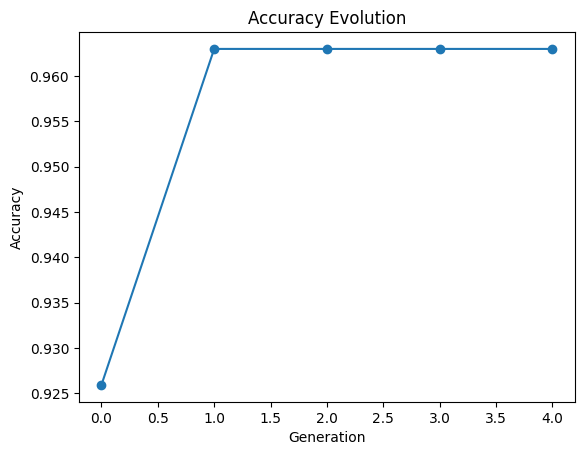

In [5]:
# Accuracy Evolution
plt.plot(history, marker="o")
plt.title("Accuracy Evolution")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.show()